## RealNVP

Preparation: imports, folders, checking variables

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display, Image, HTML
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# reproducibility
seed = 52
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

Device: cpu


Parameters + MNIST loading

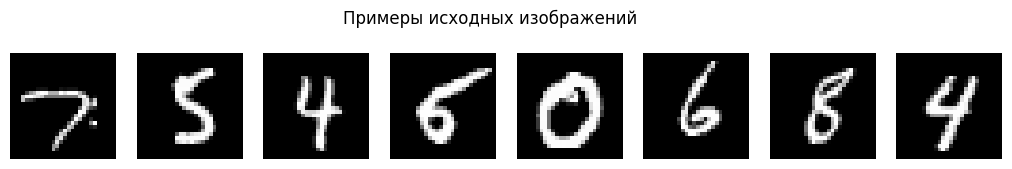

img_size=28, dim=784, subset_size=40000


In [ ]:
img_size = 28
dim = img_size * img_size
subset_size = 40000
batch_size = 256

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_train = datasets.MNIST(root='.', train=True, download=True, transform=transform)
subset = Subset(full_train, list(range(min(len(full_train), subset_size))))
train_loader = DataLoader(subset, batch_size=batch_size, shuffle=True, drop_last=True)

def show_images(tensor_images, title=None, ncol=8):
    imgs = tensor_images.detach().cpu().view(-1,1,img_size,img_size).numpy()
    n = min(len(imgs), ncol)
    fig, axes = plt.subplots(1, n, figsize=(n*1.6, 2))
    if title: fig.suptitle(title)
    for i in range(n):
        axes[i].imshow(imgs[i,0], cmap='gray')
        axes[i].axis('off')
    plt.show()

x0, _ = next(iter(train_loader))
show_images(x0[:8], "Примеры исходных изображений")
print(f"img_size={img_size}, dim={dim}, subset_size={len(subset)}")

Realization

In [ ]:
class STNet(nn.Module):
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim * 2)
        )

        for p in self.net.parameters():
            p.data *= 0.05

    def forward(self, x):
        st = self.net(x)
        s, t = st.chunk(2, dim=1)
        s = torch.tanh(s)
        return s, t

class RealNVPLayer(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()
        # mask - binary mask, which elements remain frozen
        # registers the mask so that it moves with .to(device)
        mask = mask.clone().detach().float()
        self.register_buffer('mask', mask.view(1, -1))
        self.st = STNet(dim, hidden=128)

    # layer
    def forward(self, x):
        # x: (B, dim)
        x_masked = x * self.mask
        s, t = self.st(x_masked)
        y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        logdet = ((1 - self.mask) * s).sum(dim=1)
        return y, logdet

    # reverse function for layer
    def inverse(self, y):
        y_masked = y * self.mask
        s, t = self.st(y_masked)
        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        return x

class RealNVP(nn.Module):
    def __init__(self, dim, n_coupling=4):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_coupling):
            mask = torch.zeros(dim)
            if i % 2 == 0:
                mask[::2] = 1.0
            else:
                mask[1::2] = 1.0
            self.layers.append(RealNVPLayer(dim, mask))

    # x to z
    def forward(self, x):
        logdet_total = 0
        z = x
        for layer in self.layers:
            z, ld = layer(z)
            logdet_total = logdet_total + ld
        return z, logdet_total

    # z to x
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

n_coupling = 10
realnvp = RealNVP(dim, n_coupling=n_coupling).to(device)
print("Model created. n_coupling =", n_coupling)

Model created. n_coupling = 10


Training

In [ ]:
train_losses = []
avg_logdet = []
bits_per_dim = []

opt = optim.Adam(realnvp.parameters(), lr=3e-3)
epochs = 15

realnvp.train()
for epoch in range(epochs):
    running = 0.0
    total = 0
    for x, _ in train_loader:
        x = x.to(device)
        z, logdet = realnvp(x)
        prior = -0.5 * torch.sum(z**2, dim=1)
        nll = -(prior + logdet)  # negative log-likelihood
        loss = nll.mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item() * x.size(0)
        total += x.size(0)

    epoch_loss = running / total
    train_losses.append(epoch_loss)

    with torch.no_grad():
        xb, _ = next(iter(train_loader))
        xb = xb.to(device)[:256]
        zt, ldet = realnvp(xb)
        avg_logdet.append(ldet.mean().item())
        nll_batch = (0.5 * (zt**2).sum(dim=1) - ldet).mean().item()
        bpd = nll_batch / (np.log(2) * dim)
        bits_per_dim.append(bpd)

    print(f"Epoch {epoch+1}/{epochs}: loss={epoch_loss:.4f}, avg_logdet={avg_logdet[-1]:.4f}, bpd≈{bits_per_dim[-1]:.4f}")

print("Training finished.")

Epoch 1/15: loss=-1528.2912, avg_logdet=2449.8015, bpd≈-4.0212
Epoch 2/15: loss=-2353.4322, avg_logdet=2668.1833, bpd≈-4.4707
Epoch 3/15: loss=-2526.7412, avg_logdet=2763.4067, bpd≈-4.6951
Epoch 4/15: loss=-2632.2110, avg_logdet=2869.5825, bpd≈-4.8921
Epoch 5/15: loss=-2696.7448, avg_logdet=2932.0515, bpd≈-5.0315
Epoch 6/15: loss=-2746.9094, avg_logdet=2963.4543, bpd≈-5.1064
Epoch 7/15: loss=-2766.8679, avg_logdet=2967.7349, bpd≈-5.1303
Epoch 8/15: loss=-2815.1938, avg_logdet=3018.1128, bpd≈-5.2141
Epoch 9/15: loss=-2846.9061, avg_logdet=3038.3804, bpd≈-5.2518
Epoch 10/15: loss=-2859.5659, avg_logdet=3048.5317, bpd≈-5.3003
Epoch 11/15: loss=-2885.9202, avg_logdet=3045.9656, bpd≈-5.3082
Epoch 12/15: loss=-2889.2515, avg_logdet=3070.3059, bpd≈-5.3087
Epoch 13/15: loss=-2894.5026, avg_logdet=3079.9971, bpd≈-5.3430
Epoch 14/15: loss=-2915.0945, avg_logdet=3069.3987, bpd≈-5.3420
Epoch 15/15: loss=-2921.8778, avg_logdet=3079.2971, bpd≈-5.3747
Training finished.


Training schedules: loss, avg_logdet, bits-per-dim

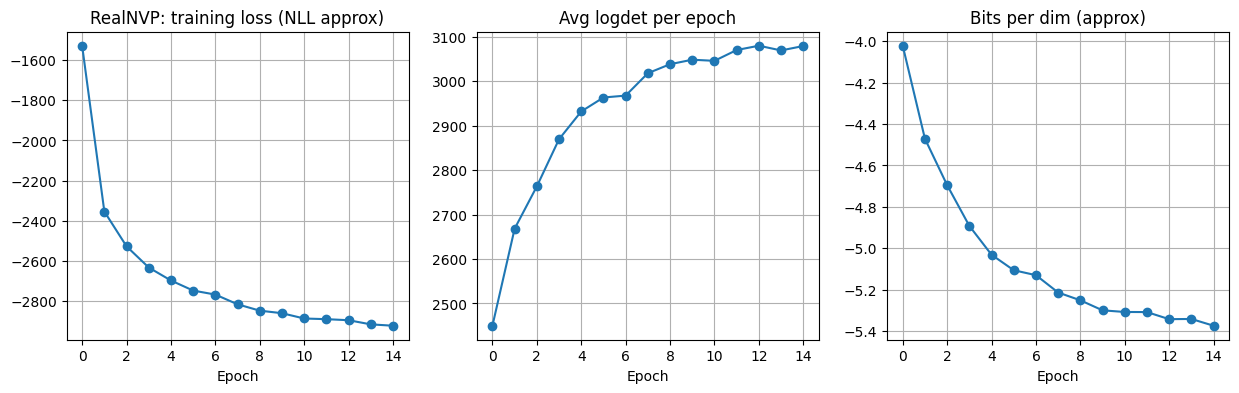

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(train_losses, marker='o')
plt.title("RealNVP: training loss (NLL approx)")
plt.xlabel("Epoch")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(avg_logdet, marker='o')
plt.title("Avg logdet per epoch")
plt.xlabel("Epoch")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(bits_per_dim, marker='o')
plt.title("Bits per dim (approx)")
plt.xlabel("Epoch")
plt.grid(True)

plt.show()

Reconstruction: x -> z - >x_rec, MSE, visualization

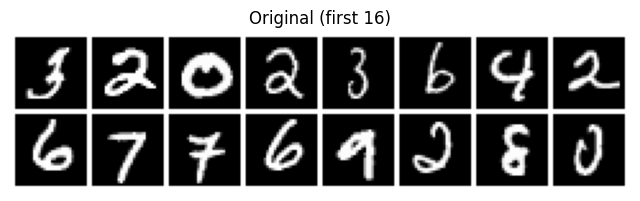

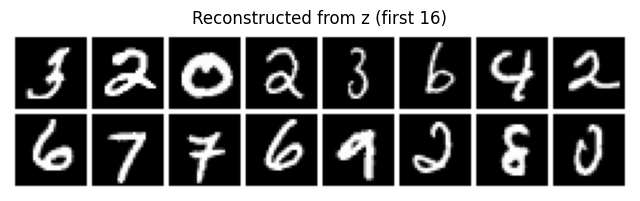

Reconstruction MSE (first 16): 3.410742062994734e-15


In [ ]:
realnvp.eval()
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    xb = xb.to(device)[:16]
    z, ld = realnvp(xb)
    xb_rec = realnvp.inverse(z)

def show_grid(tensor, title=None, nrow=8):
    grid = make_grid(tensor.view(-1,1,img_size,img_size), nrow=nrow, pad_value=1.0)
    plt.figure(figsize=(8,3))
    plt.imshow(grid.permute(1,2,0).cpu(), cmap='gray')
    plt.axis('off')
    if title: plt.title(title)
    plt.show()

show_grid(xb.cpu(), "Original (first 16)", nrow=8)
show_grid(xb_rec.cpu(), "Reconstructed from z (first 16)", nrow=8)

mse = torch.mean((xb.cpu() - xb_rec.cpu())**2).item()
print("Reconstruction MSE (first 16):", mse)

Projection of latent space
shows the distribution of points in the latent space by the first two coordinates

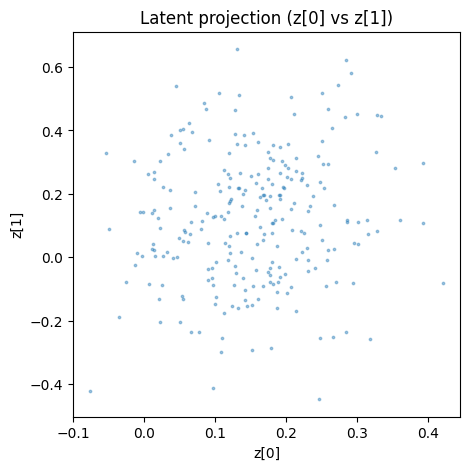

In [ ]:
with torch.no_grad():
    xb_vis, _ = next(iter(train_loader))
    xb_vis = xb_vis.to(device)[:2048]
    z_vis, _ = realnvp(xb_vis)

z_np = z_vis.cpu().numpy()
plt.figure(figsize=(5,5))
plt.scatter(z_np[:,0], z_np[:,1], s=3, alpha=0.4)
plt.title("Latent projection (z[0] vs z[1])")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

A series of images of intermediate values between two endpoints
shows how noise becomes a picture

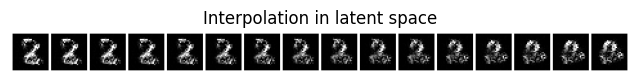

In [ ]:
n_steps = 16
with torch.no_grad():
    z1 = torch.randn(1, dim).to(device)
    z2 = torch.randn(1, dim).to(device)
    interp_imgs = []
    for a in np.linspace(0,1,n_steps):
        z = (1-a)*z1 + a*z2
        x = realnvp.inverse(z)
        interp_imgs.append(x.cpu())

interp_batch = torch.cat(interp_imgs, dim=0)
show_grid(interp_batch, title="Interpolation in latent space", nrow=n_steps)

Generating new layers
We take random noise, invert it, generate new images, which shows how the noise becomes a picture.

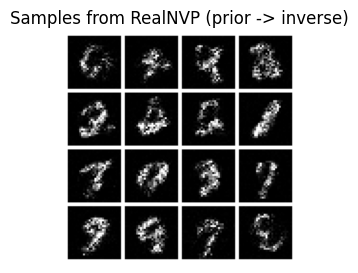

Saved samples grid: outputs/RealNVP_plots/final_samples_grid.png
Saved individual sample images in /content/outputs/RealNVP_plots


In [ ]:
n_samples = 16
z_sample = torch.randn(n_samples, dim).to(device)
with torch.no_grad():
    samples = realnvp.inverse(z_sample).cpu()

show_grid(samples, "Samples from RealNVP (prior -> inverse)", nrow=4)

out_dir_nvp = "outputs/RealNVP_plots"
os.makedirs(out_dir_nvp, exist_ok=True)
grid = make_grid(samples.view(-1,1,img_size,img_size), nrow=4, pad_value=1.0)
npimg = (grid.numpy().transpose(1,2,0) * 255).astype('uint8').squeeze()
path = os.path.join(out_dir_nvp, "final_samples_grid.png")
PILImage.fromarray(npimg).save(path)
print("Saved samples grid:", path)

for i in range(samples.shape[0]):
    im = (samples[i].view(img_size, img_size).numpy() * 255).astype('uint8')
    PILImage.fromarray(im).save(os.path.join(out_dir_nvp, f"sample_{i:02d}.png"))
print("Saved individual sample images in", os.path.abspath(out_dir_nvp))

Histogram and statistics
Check the logdet distribution for model stability

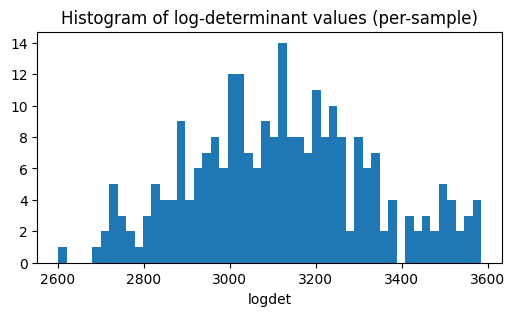

logdet mean: 3120.4111 std: 209.23894


In [ ]:
with torch.no_grad():
    xb_stat, _ = next(iter(train_loader))
    xb_stat = xb_stat.to(device)[:1024]
    _, logdet_stat = realnvp(xb_stat)

logdet_np = logdet_stat.cpu().numpy()
plt.figure(figsize=(6,3))
plt.hist(logdet_np, bins=50)
plt.title("Histogram of log-determinant values (per-sample)")
plt.xlabel("logdet")
plt.show()

print("logdet mean:", logdet_np.mean(), "std:", logdet_np.std())

Step-by-step inversion by layers
Save the intermediate results by layers and create a png

Saved: outputs/RealNVP_steps/grids_by_layer/layer_01_grid.png


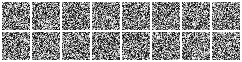

Saved: outputs/RealNVP_steps/grids_by_layer/layer_02_grid.png


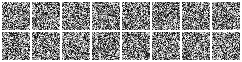

Saved: outputs/RealNVP_steps/grids_by_layer/layer_03_grid.png


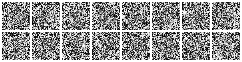

Saved: outputs/RealNVP_steps/grids_by_layer/layer_04_grid.png


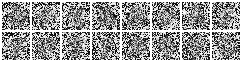

Saved: outputs/RealNVP_steps/grids_by_layer/layer_05_grid.png


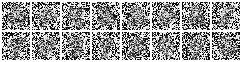

Saved: outputs/RealNVP_steps/grids_by_layer/layer_06_grid.png


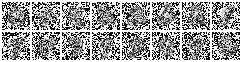

Saved: outputs/RealNVP_steps/grids_by_layer/layer_07_grid.png


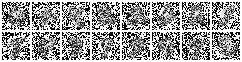

Saved: outputs/RealNVP_steps/grids_by_layer/layer_08_grid.png


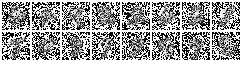

Saved: outputs/RealNVP_steps/grids_by_layer/layer_09_grid.png


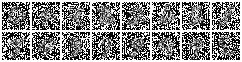

Saved: outputs/RealNVP_steps/grids_by_layer/layer_10_grid.png


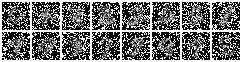

Saved sample 0 images -> outputs/RealNVP_steps/sample_pngs/sample_0
Saved sample 1 images -> outputs/RealNVP_steps/sample_pngs/sample_1
Saved sample 2 images -> outputs/RealNVP_steps/sample_pngs/sample_2
Saved sample 3 images -> outputs/RealNVP_steps/sample_pngs/sample_3
Saved sample 4 images -> outputs/RealNVP_steps/sample_pngs/sample_4
Saved sample 5 images -> outputs/RealNVP_steps/sample_pngs/sample_5
Saved sample 6 images -> outputs/RealNVP_steps/sample_pngs/sample_6
Saved sample 7 images -> outputs/RealNVP_steps/sample_pngs/sample_7
Saved sample 8 images -> outputs/RealNVP_steps/sample_pngs/sample_8
Saved sample 9 images -> outputs/RealNVP_steps/sample_pngs/sample_9
Saved sample 10 images -> outputs/RealNVP_steps/sample_pngs/sample_10
Saved sample 11 images -> outputs/RealNVP_steps/sample_pngs/sample_11
Saved sample 12 images -> outputs/RealNVP_steps/sample_pngs/sample_12
Saved sample 13 images -> outputs/RealNVP_steps/sample_pngs/sample_13
Saved sample 14 images -> outputs/RealNV

/tmp/ipython-input-1789283360.py:43: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(img_path))


Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_7_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_8_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_9_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_10_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_11_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_12_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_13_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_14_progress.gif
Saved GIF: outputs/RealNVP_steps/gifs_per_sample/sample_15_progress.gif
Saved combined GIF: outputs/RealNVP_steps/all_samples_by_layer_grid.gif


/tmp/ipython-input-1789283360.py:52: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(p))


In [ ]:
try:
    z_sample
except NameError:
    z_sample = torch.randn(8, dim).to(device)
    print("z_sample was missing — сгенерирован новый.")

realnvp.eval()
with torch.no_grad():
    x_curr = z_sample
    intermediates = []
    for layer in reversed(realnvp.layers):
        x_curr = layer.inverse(x_curr)
        intermediates.append(x_curr.cpu().clone())

out_dir_steps = os.path.join("outputs", "RealNVP_steps")
os.makedirs(out_dir_steps, exist_ok=True)
os.makedirs(os.path.join(out_dir_steps, "grids_by_layer"), exist_ok=True)
os.makedirs(os.path.join(out_dir_steps, "sample_pngs"), exist_ok=True)
os.makedirs(os.path.join(out_dir_steps, "gifs_per_sample"), exist_ok=True)

for i, imgs in enumerate(intermediates, start=1):
    grid = make_grid(imgs.view(-1,1,img_size,img_size), nrow=8, pad_value=1.0)
    npimg = (grid.numpy().transpose(1,2,0) * 255).astype('uint8').squeeze()
    p = os.path.join(out_dir_steps, "grids_by_layer", f"layer_{i:02d}_grid.png")
    PILImage.fromarray(npimg).save(p)
    print("Saved:", p)
    display(Image(filename=p))

n_samples = intermediates[0].shape[0]
for s in range(n_samples):
    sample_dir = os.path.join(out_dir_steps, "sample_pngs", f"sample_{s}")
    os.makedirs(sample_dir, exist_ok=True)
    for layer_idx, imgs in enumerate(intermediates, start=1):
        im = (imgs[s].view(img_size, img_size).numpy() * 255).astype('uint8')
        p = os.path.join(sample_dir, f"layer_{layer_idx:02d}.png")
        PILImage.fromarray(im).save(p)
    print("Saved sample", s, "images ->", sample_dir)

for s in range(n_samples):
    frames = []
    for layer_idx in range(len(intermediates)):
        img_path = os.path.join(out_dir_steps, "sample_pngs", f"sample_{s}", f"layer_{layer_idx+1:02d}.png")
        frames.append(imageio.imread(img_path))
    gif_path = os.path.join(out_dir_steps, "gifs_per_sample", f"sample_{s}_progress.gif")
    imageio.mimsave(gif_path, frames, duration=0.7)
    print("Saved GIF:", gif_path)
    # display(HTML(f'<img src="{gif_path}" width="256">'))

frames = []
for layer_idx in range(len(intermediates)):
    p = os.path.join(out_dir_steps, "grids_by_layer", f"layer_{layer_idx+1:02d}_grid.png")
    frames.append(imageio.imread(p))
out_gif = os.path.join(out_dir_steps, "all_samples_by_layer_grid.gif")
imageio.mimsave(out_gif, frames, duration=1.0)
print("Saved combined GIF:", out_gif)
# display(HTML(f'<img src="{out_gif}" width="512">'))

Generating images

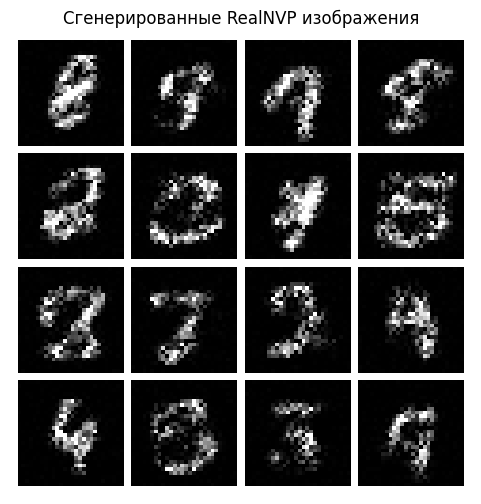

In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_samples = 16
dim = 28*28
img_size = int(dim**0.5)

z = torch.randn(n_samples, dim).to(device)

realnvp.eval()
with torch.no_grad():
    samples = realnvp.inverse(z).cpu()

grid = make_grid(samples.view(-1,1,img_size,img_size), nrow=4, pad_value=1.0)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0), cmap='gray')
plt.axis('off')
plt.title("Generated RealNVP Images")
plt.show()

Saving the model's checkpoint

In [ ]:
ckpt = {
    "model_state_dict": realnvp.state_dict(),
    "dim": dim,
    "img_size": img_size,
    "n_coupling": n_coupling
}
ckpt_path = os.path.join("outputs", "realnvp_checkpoint.pth")
torch.save(ckpt, ckpt_path)
print("Saved checkpoint:", ckpt_path)

Saved checkpoint: outputs/realnvp_checkpoint.pth
